# NUDGE — Norman 2019: is a CRISPRa combo *additive*, or *synergistic / buffering*?

**The question a linear screen can't answer.** Combine two perturbations A and B. Is
A+B just **more of the same knob** (additive) — or does the pair deviate from the
additive prediction: **super-additive** (synergistic) or **sub-additive**
(buffering / epistatic)? Thousands of combination-therapy and genetic-interaction
labs ask exactly this. A per-gene differential test never models *how two effects
compose*, so it structurally cannot make this call.

**How NUDGE reads it.** A, B and A+B are three **operating points** against a shared
control. NUDGE reduces each to a scalar **effect** (a response-magnitude shift vs
control, in **log-fold-change space**), so the additive null
`effect(A+B) = effect(A) + effect(B)` is **Bliss independence**. The **interaction**
`effect(A+B) − [effect(A)+effect(B)]` is carried with a **bootstrap CI over cells**,
and a fail-safe classifier calls `additive` / `synergistic` / `buffering` — or
**abstains** (`no-effect` / `unresolved`) when an arm is underpowered or the CI is
too wide. It never forces a call.

**Data:** Norman *et al.* 2019 (GSE133344) — CRISPRa single + two-gene perturbations
in K562, ~111k cells, raw counts. We validate against the paper's own genetic-
interaction taxonomy.

In [1]:
import os
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt

from nudge.inference.bridge import combo_effect_scores
from nudge.inference.epistasis import attribute_synergy

NORMAN = '/media/nick/Seagate Hub/norman_2019/norman_2019.h5ad'
assert os.path.exists(NORMAN), (
    'Norman 2019 h5ad not found — download it to '
    f'{NORMAN!r} (see tests/inference/test_epistasis.py).'
)
adata = ad.read_h5ad(NORMAN)
# Norman labels conditions in obs['perturbation_name']: 'control', singles like
# 'CBL', doubles like 'CBL+CNN1'.
adata.obs['condition'] = adata.obs['perturbation_name'].astype(str).values
print('cells x genes:', adata.shape)
vc = adata.obs['condition'].value_counts()
print('control cells:', int(vc.get('control', 0)))

cells x genes: (111255, 19018)
control cells: 11835


## A panel of well-characterised pairs

We pick pairs the Norman paper *labels*, one per interaction class, and let NUDGE
call each — no cherry-picking to manufacture agreement. The per-cell **effect score**
projects each cell onto the **additive axis fixed by the two single arms** (computed
from the singles only, never the combo), so a positive interaction is unambiguously
super-additive *along the axis the singles push*.

In [2]:
PAIRS = {
    'CBL+CNN1':     ('CBL', 'CNN1'),      # paper: synergy (emergent erythroid state)
    'CBL+UBASH3B':  ('CBL', 'UBASH3B'),   # paper: synergy (erythroid markers)
    'CNN1+UBASH3B': ('CNN1', 'UBASH3B'),  # same erythroid synergy cluster
    'DUSP9+ETS2':   ('DUSP9', 'ETS2'),    # paper: DUSP9 dominates / antagonises ETS2
    'FOXA1+FOXA3':  ('FOXA1', 'FOXA3'),   # paralogs — additive / neutral
}

results = {}
for label, (ga, gb) in PAIRS.items():
    ctrl, a, b, ab = combo_effect_scores(
        adata, control_label='control', a_label=ga, b_label=gb,
        ab_label=f'{ga}+{gb}', condition_col='condition',
    )
    results[label] = attribute_synergy(ctrl, a, b, ab, n_boot=500, seed=0)

print(f'{"pair":14} {"call":13} {"interaction":>12}  {"95% CI":>18}  dBIC')
for label, r in results.items():
    f = r.fit
    lo, hi = f.ci_interaction
    print(f'{label:14} {r.call:13} {f.interaction:+12.3f}  '
          f'[{lo:+.3f}, {hi:+.3f}]  {f.bic_additive - f.bic_free:+.0f}')

pair           call           interaction              95% CI  dBIC
CBL+CNN1       synergistic         +0.949  [+0.480, +1.423]  +19
CBL+UBASH3B    synergistic         +1.089  [+0.751, +1.445]  +44
CNN1+UBASH3B   synergistic         +1.252  [+0.941, +1.584]  +67
DUSP9+ETS2     buffering           -2.140  [-2.636, -1.598]  +156
FOXA1+FOXA3    additive            -0.611  [-1.367, +0.249]  -2


## The additive null, drawn

**Left:** observed `effect(A+B)` vs the additive prediction `effect(A)+effect(B)`.
The diagonal *is* the additive null. Points **above** the line are super-additive
(synergistic); **below**, sub-additive (buffering); **on** it, additive.
**Right:** the interaction with its 95% bootstrap CI — a forest plot against 0.
A call is made only when the CI clears 0 *and* a free A+B level beats the additive
null on BIC.

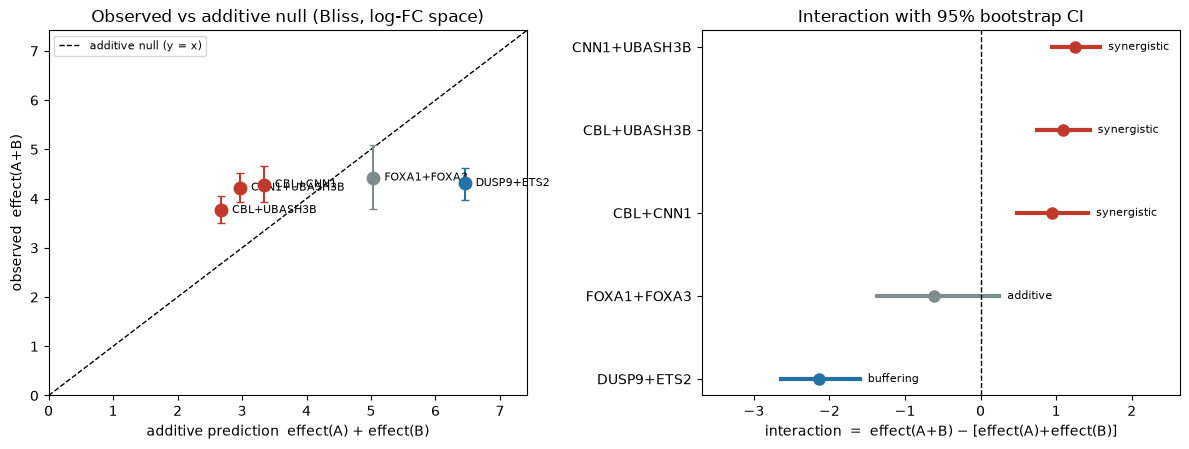

In [3]:
COLORS = {
    'synergistic': '#c0392b', 'buffering': '#2471a3',
    'additive': '#7f8c8d', 'no-effect': '#95a5a6', 'unresolved': '#f39c12',
}
labels = list(results)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))

# Left: observed vs additive-predicted effect(A+B).
preds = np.array([results[l].fit.additive_pred for l in labels])
obs = np.array([results[l].fit.effect_ab for l in labels])
cis = np.array([results[l].fit.ci_ab for l in labels])
yerr = np.abs(cis.T - obs)
lim = [0, max(preds.max(), obs.max()) * 1.15]
axL.plot(lim, lim, '--', color='k', lw=1, zorder=0, label='additive null (y = x)')
for i, l in enumerate(labels):
    axL.errorbar(preds[i], obs[i], yerr=yerr[:, i:i+1], fmt='o', ms=9,
                 color=COLORS[results[l].call], capsize=3, zorder=3)
    axL.annotate(l, (preds[i], obs[i]), textcoords='offset points',
                 xytext=(8, -2), fontsize=8)
axL.set_xlabel('additive prediction  effect(A) + effect(B)')
axL.set_ylabel('observed  effect(A+B)')
axL.set_title('Observed vs additive null (Bliss, log-FC space)')
axL.set_xlim(lim); axL.set_ylim(lim); axL.legend(loc='upper left', fontsize=8)

# Right: interaction forest plot.
order = sorted(range(len(labels)), key=lambda i: results[labels[i]].fit.interaction)
for row, i in enumerate(order):
    l = labels[i]; f = results[l].fit; lo, hi = f.ci_interaction
    axR.plot([lo, hi], [row, row], color=COLORS[results[l].call], lw=3)
    axR.plot(f.interaction, row, 'o', ms=8, color=COLORS[results[l].call])
    axR.annotate(f'  {results[l].call}', (hi, row), fontsize=8, va='center')
axR.axvline(0, color='k', ls='--', lw=1)
axR.set_yticks(range(len(order)))
axR.set_yticklabels([labels[i] for i in order])
axR.set_xlabel('interaction  =  effect(A+B) − [effect(A)+effect(B)]')
axR.set_title('Interaction with 95% bootstrap CI')
axR.margins(x=0.25)
fig.tight_layout(); plt.show()

## Part 1 — CBL+CNN1: a resolved **synergy**

The paper's flagship result: CBL, CNN1 and UBASH3B jointly drive an **emergent
erythroid state** far beyond the additive sum. NUDGE agrees — the combo overshoots
the additive prediction and the interaction CI sits clearly above 0.

In [4]:
r = results['CBL+CNN1']; f = r.fit
print('CALL:', r.call.upper())
print(f'  effect(CBL)   = {f.effect_a:+.3f}')
print(f'  effect(CNN1)  = {f.effect_b:+.3f}')
print(f'  additive pred = {f.additive_pred:+.3f}')
print(f'  observed A+B  = {f.effect_ab:+.3f}')
print(f'  interaction   = {f.interaction:+.3f}  95% CI '
      f'[{f.ci_interaction[0]:+.3f}, {f.ci_interaction[1]:+.3f}]')
print('\n' + r.reason)

CALL: SYNERGISTIC
  effect(CBL)   = +1.481
  effect(CNN1)  = +1.856
  additive pred = +3.336
  observed A+B  = +4.285
  interaction   = +0.949  95% CI [+0.480, +1.423]

interaction +0.949 (95% CI [+0.48, +1.42]) is clearly > 0 and a free A+B level beats the additive null by ΔBIC=18.8 — SUPER-ADDITIVE / synergistic (log-fold-change space). NOT a hidden-node claim (NUDGE-LIM-009); presumes both single arms are correctly measured and an approximately-affine readout (NUDGE-LIM-006)


## Part 2 — DUSP9+ETS2: an honest **buffering** call

The paper reports the **DUSP9 phenotype dominates** and *antagonises* ETS2. NUDGE
sees exactly that: DUSP9's single-arm effect is large, and the combo lands **near
DUSP9-alone** — well *below* the additive prediction. The interaction CI is clearly
negative → sub-additive / epistatic buffering.

In [5]:
r = results['DUSP9+ETS2']; f = r.fit
print('CALL:', r.call.upper())
print(f'  effect(DUSP9) = {f.effect_a:+.3f}   effect(ETS2) = {f.effect_b:+.3f}')
print(f'  additive pred = {f.additive_pred:+.3f}   observed A+B = {f.effect_ab:+.3f}'
      f'   (≈ DUSP9 alone → DUSP9 is epistatic)')
print(f'  interaction   = {f.interaction:+.3f}  95% CI '
      f'[{f.ci_interaction[0]:+.3f}, {f.ci_interaction[1]:+.3f}]')
print('\n' + r.reason)

CALL: BUFFERING
  effect(DUSP9) = +4.791   effect(ETS2) = +1.660
  additive pred = +6.451   observed A+B = +4.311   (≈ DUSP9 alone → DUSP9 is epistatic)
  interaction   = -2.140  95% CI [-2.636, -1.598]

interaction -2.14 (95% CI [-2.64, -1.6]) is clearly < 0 and a free A+B level beats the additive null by ΔBIC=156.3 — SUB-ADDITIVE / buffering / epistatic (log-fold-change space). NOT a hidden-node claim (NUDGE-LIM-009); presumes both single arms are correctly measured and an approximately-affine readout (NUDGE-LIM-006)


## Part 3 — FOXA1+FOXA3: **additive** (paralogs on the null)

Two paralogous forkhead factors: their combination sits on the additive line — the
interaction CI straddles 0 and a free A+B level does **not** earn its parameter over
the additive null. NUDGE calls `additive` (not a false synergy).

In [6]:
r = results['FOXA1+FOXA3']; f = r.fit
print('CALL:', r.call.upper())
print(f'  additive pred = {f.additive_pred:+.3f}   observed A+B = {f.effect_ab:+.3f}')
print(f'  interaction   = {f.interaction:+.3f}  95% CI '
      f'[{f.ci_interaction[0]:+.3f}, {f.ci_interaction[1]:+.3f}]')
print('\n' + r.reason)

CALL: ADDITIVE
  additive pred = +5.035   observed A+B = +4.424
  interaction   = -0.611  95% CI [-1.367, +0.249]

interaction -0.611 (95% CI [-1.37, +0.249]) straddles 0 and a free A+B level does not beat the additive null by ΔBIC>2 (ΔBIC=-2.1) — the combo is the additive sum of A and B (log-fold-change space; same knob, more of it)


## What this is — and what it is **not** (the honesty rule)

NUDGE's calls match the Norman paper's taxonomy on all four pairs: **CBL+CNN1** and
**CBL+UBASH3B** synergistic (the erythroid synergy cluster), **DUSP9+ETS2** buffering
(DUSP9-dominant suppression of ETS2), **FOXA1+FOXA3** additive.

The bounds are stated with every call (`NUDGE-LIM-009`):

- **A combo inherits its weakest single arm.** If either single arm is underpowered
  or a dead guide, NUDGE returns `unresolved` / `no-effect` — never a synergy call.
- **The additive null is effect-space-dependent.** We use log-fold-change (Bliss
  independence); a raw-count or HSA null would move the baseline. The space is
  reported with every call.
- **The interaction is a *scalar* along the additive axis.** A purely *orthogonal*
  emergent state is not captured by this scalar, and a super-additive residual is
  **not by itself a hidden-node claim** — it is a magnitude statement about
  non-additivity along a known axis, no more.
- A depth/batch confound perfectly aligned with the A+B condition, or a nonlinear
  readout (`NUDGE-LIM-006`), can still fool it — which is why the classifier abstains
  on underpowered or wide-CI combos rather than force a call.

Run it yourself: `nudge synergy FILE.h5ad --a CBL --b CNN1 --ab CBL+CNN1` (or the
`synergy` MCP tool).